In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

=== ROCKET PROPULSION PERFORMANCE ===
          Pc_MPa  Tc_K  At_m2  Ae_m2  Expansion_ratio  Mach_exit  \
Chemical       7  3500   0.01    0.2             20.0       3.84   
NTP            7  3500   0.01    0.2             20.0       4.73   

          Mass_flow_kg_s  Exit_temperature_K  Exit_pressure_Pa  \
Chemical           40.97             1333.52          33203.13   
NTP                12.62              640.32          18333.31   

          Exit_velocity_m_s   Thrust_N  Specific_impulse_s  
Chemical            2920.62  126295.24              314.24  
NTP                 9085.89  118295.08              955.81  


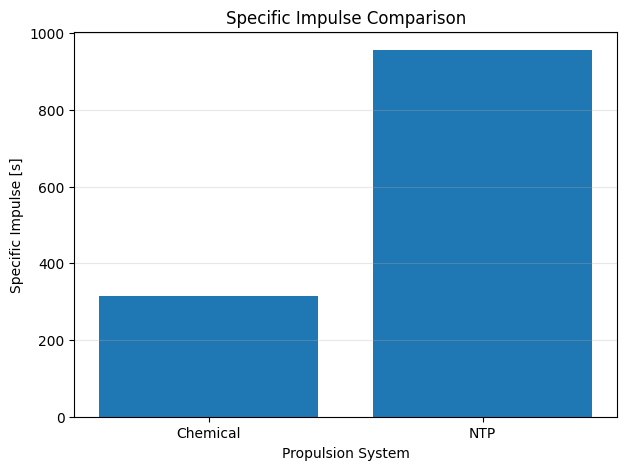

In [ ]:
# ============================================
# ROCKET PROPULSION PROJECT
# Chemical vs Nuclear Thermal Propulsion (NTP)
# ============================================

import math
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# AREA RATIO FUNCTION
# --------------------------------------------------
def area_ratio(M, gamma):
    """
    Calcola il rapporto A/A* per un dato numero di Mach.
    """

    return (1 / M) * (
        (2 / (gamma + 1))
        * (1 + ((gamma - 1) / 2) * M**2)
    ) ** ((gamma + 1) / (2 * (gamma - 1)))


# --------------------------------------------------
# FIND EXIT MACH WITH BISECTION
# --------------------------------------------------
def find_exit_mach(expansion_ratio, gamma):
    """
    Trova il Mach supersonico corrispondente
    al rapporto di espansione Ae/At.

    Usiamo il metodo di bisezione:
    restringiamo progressivamente l'intervallo
    finché troviamo il valore corretto.
    """

    M_low = 1.0001
    M_high = 10.0

    for _ in range(200):

        M_mid = (M_low + M_high) / 2

        epsilon_mid = area_ratio(M_mid, gamma)

        if epsilon_mid < expansion_ratio:
            M_low = M_mid
        else:
            M_high = M_mid

    return (M_low + M_high) / 2


# --------------------------------------------------
# MAIN ROCKET PERFORMANCE FUNCTION
# --------------------------------------------------
def rocket_performance(
    Pc_MPa,
    Tc,
    At,
    Ae,
    gamma,
    R,
    Pa
):

    # Pressione camera: MPa -> Pa
    Pc = Pc_MPa * 1_000_000

    # Rapporto di espansione
    expansion_ratio = Ae / At

    # Mach di uscita
    Me = find_exit_mach(
        expansion_ratio,
        gamma
    )

    # Portata massica
    mdot = (
        At
        * Pc
        * math.sqrt(gamma / (R * Tc))
        * (2 / (gamma + 1))
        ** ((gamma + 1) / (2 * (gamma - 1)))
    )

    # Temperatura di uscita
    Te = Tc / (
        1 + ((gamma - 1) / 2) * Me**2
    )

    # Pressione di uscita
    Pe = Pc / (
        1 + ((gamma - 1) / 2) * Me**2
    ) ** (gamma / (gamma - 1))

    # Velocità locale del suono
    ae = math.sqrt(
        gamma * R * Te
    )

    # Velocità dei gas all'uscita
    Ve = Me * ae

    # Spinta
    F = (
        mdot * Ve
        + (Pe - Pa) * Ae
    )

    # Accelerazione di gravità standard
    g0 = 9.81

    # Impulso specifico
    Isp = F / (mdot * g0)

    return {
        "Pc_MPa": Pc_MPa,
        "Tc_K": Tc,
        "At_m2": At,
        "Ae_m2": Ae,
        "Expansion_ratio": expansion_ratio,
        "Mach_exit": Me,
        "Mass_flow_kg_s": mdot,
        "Exit_temperature_K": Te,
        "Exit_pressure_Pa": Pe,
        "Exit_velocity_m_s": Ve,
        "Thrust_N": F,
        "Specific_impulse_s": Isp
    }


# ==================================================
# CHEMICAL PROPULSION
# ==================================================

chemical = rocket_performance(
    Pc_MPa=7,
    Tc=3500,
    At=0.01,
    Ae=0.20,
    gamma=1.22,
    R=355,
    Pa=0
)


# ==================================================
# NUCLEAR THERMAL PROPULSION
# ==================================================

ntp = rocket_performance(
    Pc_MPa=7,
    Tc=3500,
    At=0.01,
    Ae=0.20,
    gamma=1.40,
    R=4124,
    Pa=0
)


# --------------------------------------------------
# RESULTS TABLE
# --------------------------------------------------

results = pd.DataFrame(
    [chemical, ntp],
    index=["Chemical", "NTP"]
)

print("=== ROCKET PROPULSION PERFORMANCE ===")
print(results.round(2))


# --------------------------------------------------
# SPECIFIC IMPULSE GRAPH
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    ["Chemical", "NTP"],
    [
        chemical["Specific_impulse_s"],
        ntp["Specific_impulse_s"]
    ]
)

plt.title("Specific Impulse Comparison")
plt.ylabel("Specific Impulse [s]")
plt.xlabel("Propulsion System")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# PARAMETRIC ANALYSIS - CHEMICAL PROPULSION
# ============================================================

import numpy as np

# Creiamo diversi valori da provare automaticamente

# Pressione camera: da 3 a 12 MPa
pressures = np.linspace(3, 12, 10)

# Temperatura camera: da 2500 a 4000 K
temperatures = np.linspace(2500, 4000, 10)

# Rapporto di espansione: da 10 a 40
expansion_ratios = np.linspace(10, 40, 10)

# Qui salveremo tutti i risultati
simulation_results = []

# Manteniamo fissa l'area della gola
At = 0.01


# ------------------------------------------------------------
# GENERAZIONE DELLE CONFIGURAZIONI
# ------------------------------------------------------------

for Pc in pressures:

    for Tc in temperatures:

        for epsilon in expansion_ratios:

            # epsilon = Ae / At
            # quindi Ae = epsilon * At

            Ae = epsilon * At

            # Calcoliamo le prestazioni
            result = rocket_performance(
                Pc_MPa=Pc,
                Tc=Tc,
                At=At,
                Ae=Ae,
                gamma=1.22,
                R=355,
                Pa=0
            )

            # Aggiungiamo il tipo di sistema
            result["System"] = "Chemical"

            # Salviamo il risultato
            simulation_results.append(result)


# ------------------------------------------------------------
# CREAZIONE DEL DATASET
# ------------------------------------------------------------

df_chemical = pd.DataFrame(simulation_results)


print("====================================")
print("PARAMETRIC SIMULATION COMPLETED")
print("====================================")

print("\nNumber of simulations:")
print(len(df_chemical))

print("\nFirst 10 simulations:")
print(df_chemical.head(10).round(2))

PARAMETRIC SIMULATION COMPLETED

Number of simulations:
1000

First 10 simulations:
   Pc_MPa    Tc_K  At_m2  Ae_m2  Expansion_ratio  Mach_exit  Mass_flow_kg_s  \
0     3.0  2500.0   0.01   0.10            10.00       3.34           20.78   
1     3.0  2500.0   0.01   0.13            13.33       3.55           20.78   
2     3.0  2500.0   0.01   0.17            16.67       3.71           20.78   
3     3.0  2500.0   0.01   0.20            20.00       3.84           20.78   
4     3.0  2500.0   0.01   0.23            23.33       3.96           20.78   
5     3.0  2500.0   0.01   0.27            26.67       4.05           20.78   
6     3.0  2500.0   0.01   0.30            30.00       4.14           20.78   
7     3.0  2500.0   0.01   0.33            33.33       4.22           20.78   
8     3.0  2500.0   0.01   0.37            36.67       4.29           20.78   
9     3.0  2500.0   0.01   0.40            40.00       4.36           20.78   

   Exit_temperature_K  Exit_pressure_Pa  Exit_

In [ ]:
# ============================================================
# PARAMETRIC ANALYSIS - NUCLEAR THERMAL PROPULSION
# ============================================================

ntp_results = []

# Manteniamo la stessa area della gola
At = 0.01


# ------------------------------------------------------------
# GENERAZIONE DELLE CONFIGURAZIONI NTP
# ------------------------------------------------------------

for Pc in pressures:

    for Tc in temperatures:

        for epsilon in expansion_ratios:

            # Calcoliamo l'area di uscita
            Ae = epsilon * At

            # Calcolo prestazioni NTP
            result = rocket_performance(
                Pc_MPa=Pc,
                Tc=Tc,
                At=At,
                Ae=Ae,
                gamma=1.40,
                R=4124,
                Pa=0
            )

            # Identifichiamo il tipo di sistema
            result["System"] = "NTP"

            # Salviamo il risultato
            ntp_results.append(result)


# ------------------------------------------------------------
# CREAZIONE DEL DATASET NTP
# ------------------------------------------------------------

df_ntp = pd.DataFrame(ntp_results)


print("====================================")
print("NTP PARAMETRIC SIMULATION COMPLETED")
print("====================================")

print("\nNumber of simulations:")
print(len(df_ntp))

print("\nFirst 10 simulations:")
print(df_ntp.head(10).round(2))

NTP PARAMETRIC SIMULATION COMPLETED

Number of simulations:
1000

First 10 simulations:
   Pc_MPa    Tc_K  At_m2  Ae_m2  Expansion_ratio  Mach_exit  Mass_flow_kg_s  \
0     3.0  2500.0   0.01   0.10            10.00       3.92             6.4   
1     3.0  2500.0   0.01   0.13            13.33       4.25             6.4   
2     3.0  2500.0   0.01   0.17            16.67       4.51             6.4   
3     3.0  2500.0   0.01   0.20            20.00       4.73             6.4   
4     3.0  2500.0   0.01   0.23            23.33       4.91             6.4   
5     3.0  2500.0   0.01   0.27            26.67       5.08             6.4   
6     3.0  2500.0   0.01   0.30            30.00       5.23             6.4   
7     3.0  2500.0   0.01   0.33            33.33       5.37             6.4   
8     3.0  2500.0   0.01   0.37            36.67       5.49             6.4   
9     3.0  2500.0   0.01   0.40            40.00       5.61             6.4   

   Exit_temperature_K  Exit_pressure_Pa  E

In [ ]:
# ============================================================
# MERGE DATASETS
# ============================================================

df_all = pd.concat(
    [df_chemical, df_ntp],
    ignore_index=True
)

print("Total simulations:")
print(len(df_all))

print("\nFirst rows:")
print(df_all.head().round(2))

Total simulations:
2000

First rows:
   Pc_MPa    Tc_K  At_m2  Ae_m2  Expansion_ratio  Mach_exit  Mass_flow_kg_s  \
0     3.0  2500.0   0.01   0.10            10.00       3.34           20.78   
1     3.0  2500.0   0.01   0.13            13.33       3.55           20.78   
2     3.0  2500.0   0.01   0.17            16.67       3.71           20.78   
3     3.0  2500.0   0.01   0.20            20.00       3.84           20.78   
4     3.0  2500.0   0.01   0.23            23.33       3.96           20.78   

   Exit_temperature_K  Exit_pressure_Pa  Exit_velocity_m_s  Thrust_N  \
0             1123.84          35607.59            2327.73  51919.41   
1             1048.77          24268.70            2390.37  52895.94   
2              994.50          18075.51            2434.66  53592.66   
3              952.52          14229.91            2468.37  54126.53   
4              918.56          11635.28            2495.31  54555.03   

   Specific_impulse_s    System  
0              254.75

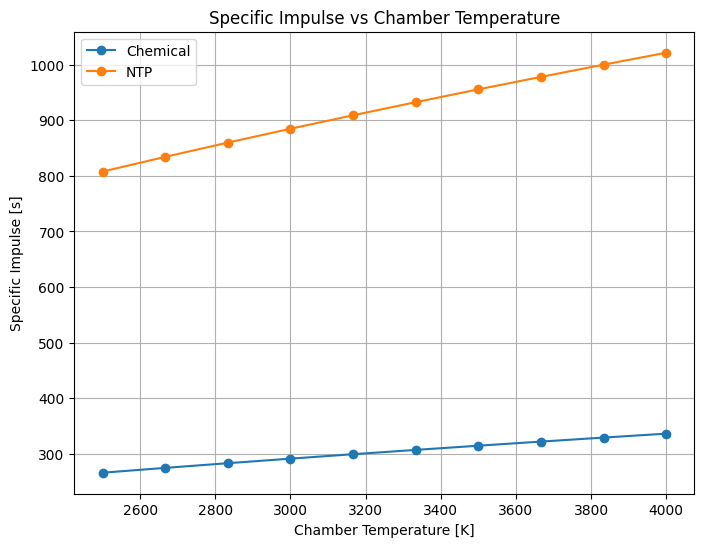

In [ ]:
# ============================================================
# SPECIFIC IMPULSE VS CHAMBER TEMPERATURE
# ============================================================

plt.figure(figsize=(8, 6))

for system in ["Chemical", "NTP"]:

    subset = df_all[
        (df_all["System"] == system)
        & (df_all["Pc_MPa"] == 7)
        & (df_all["Expansion_ratio"] == 20)
    ]

    plt.plot(
        subset["Tc_K"],
        subset["Specific_impulse_s"],
        marker="o",
        label=system
    )

plt.title("Specific Impulse vs Chamber Temperature")
plt.xlabel("Chamber Temperature [K]")
plt.ylabel("Specific Impulse [s]")

plt.grid(True)
plt.legend()

plt.show()

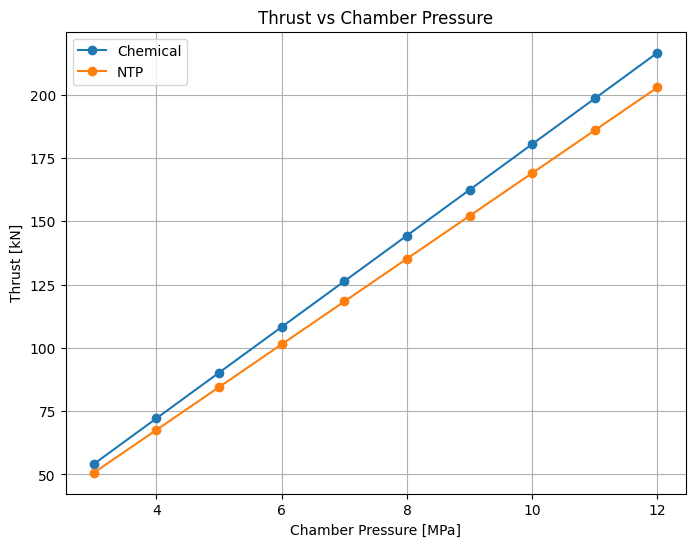

In [ ]:
# ============================================================
# THRUST VS CHAMBER PRESSURE
# ============================================================

plt.figure(figsize=(8, 6))

for system in ["Chemical", "NTP"]:

    # Prendiamo solo i dati del sistema che ci interessa
    subset = df_all[
        (df_all["System"] == system)
        & (df_all["Tc_K"] == 3500)
        & (df_all["Expansion_ratio"] == 20)
    ]

    # Disegniamo la curva pressione -> spinta
    plt.plot(
        subset["Pc_MPa"],
        subset["Thrust_N"] / 1000,
        marker="o",
        label=system
    )

plt.title("Thrust vs Chamber Pressure")

plt.xlabel("Chamber Pressure [MPa]")
plt.ylabel("Thrust [kN]")

plt.grid(True)
plt.legend()

plt.show()

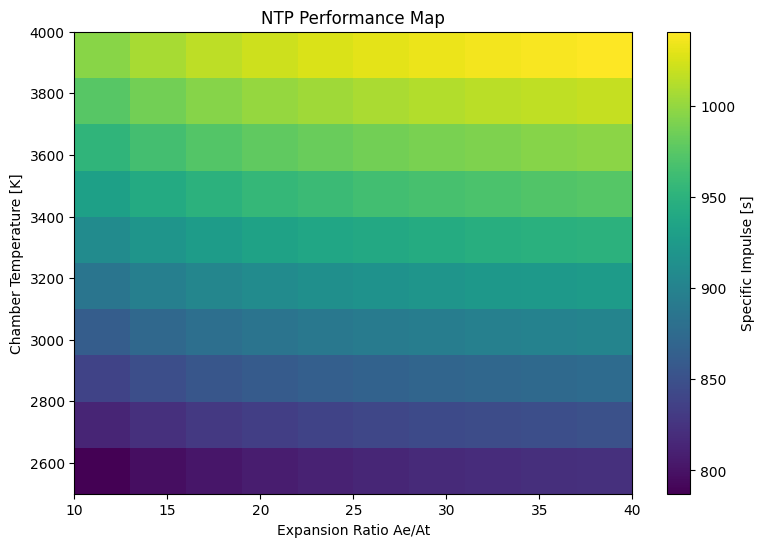

In [ ]:
# ============================================================
# PERFORMANCE MAP - SPECIFIC IMPULSE
# ============================================================

# Selezioniamo solo il sistema NTP
# e fissiamo la pressione a 7 MPa

map_data = df_all[
    (df_all["System"] == "NTP")
    & (df_all["Pc_MPa"] == 7)
]

# Creiamo una tabella 2D:
# righe = temperatura
# colonne = rapporto di espansione
# valori = impulso specifico

pivot_table = map_data.pivot(
    index="Tc_K",
    columns="Expansion_ratio",
    values="Specific_impulse_s"
)

# Creiamo la figura
plt.figure(figsize=(9, 6))

# Disegniamo la mappa
plt.imshow(
    pivot_table,
    aspect="auto",
    origin="lower",
    extent=[
        pivot_table.columns.min(),
        pivot_table.columns.max(),
        pivot_table.index.min(),
        pivot_table.index.max()
    ]
)

# Barra laterale con i valori di Isp
plt.colorbar(label="Specific Impulse [s]")

plt.title("NTP Performance Map")

plt.xlabel("Expansion Ratio Ae/At")
plt.ylabel("Chamber Temperature [K]")

plt.show()

In [ ]:
# ============================================================
# OPTIMIZATION - BEST CONFIGURATIONS
# ============================================================

# Convertiamo la soglia di spinta:
# 100 kN = 100000 N

minimum_thrust = 100000

# Filtriamo solo le configurazioni
# con spinta maggiore o uguale a 100 kN

feasible = df_all[
    df_all["Thrust_N"] >= minimum_thrust
].copy()

print("Feasible configurations:")
print(len(feasible))


# ------------------------------------------------------------
# MIGLIORE CONFIGURAZIONE PER IMPULSO SPECIFICO
# ------------------------------------------------------------

best_isp = feasible.loc[
    feasible["Specific_impulse_s"].idxmax()
]

print("\n====================================")
print("BEST CONFIGURATION BY SPECIFIC IMPULSE")
print("====================================")

print(best_isp)


# ------------------------------------------------------------
# TOP 10 CONFIGURATIONS
# ------------------------------------------------------------

top10 = feasible.sort_values(
    by="Specific_impulse_s",
    ascending=False
).head(10)

print("\n====================================")
print("TOP 10 CONFIGURATIONS")
print("====================================")

print(
    top10[
        [
            "System",
            "Pc_MPa",
            "Tc_K",
            "Expansion_ratio",
            "Mass_flow_kg_s",
            "Thrust_N",
            "Specific_impulse_s"
        ]
    ].round(2)
)

Feasible configurations:
1380

BEST CONFIGURATION BY SPECIFIC IMPULSE
Pc_MPa                          7.0
Tc_K                         4000.0
At_m2                          0.01
Ae_m2                           0.4
Expansion_ratio                40.0
Mach_exit                  5.608746
Mass_flow_kg_s            11.801277
Exit_temperature_K        548.57604
Exit_pressure_Pa        6686.779354
Exit_velocity_m_s       9981.768725
Thrust_N              120472.327106
Specific_impulse_s      1040.613118
System                          NTP
Name: 1499, dtype: object

TOP 10 CONFIGURATIONS
     System  Pc_MPa    Tc_K  Expansion_ratio  Mass_flow_kg_s   Thrust_N  \
1499    NTP     7.0  4000.0            40.00           11.80  120472.33   
1599    NTP     8.0  4000.0            40.00           13.49  137682.66   
1699    NTP     9.0  4000.0            40.00           15.17  154892.99   
1899    NTP    11.0  4000.0            40.00           18.54  189313.66   
1799    NTP    10.0  4000.0           

PARETO OPTIMAL CONFIGURATIONS
Number of Pareto configurations:
2
     System  Pc_MPa    Tc_K  Expansion_ratio  Mass_flow_kg_s   Thrust_N  \
1499    NTP     7.0  4000.0             40.0           11.80  120472.33   
1399    NTP     6.0  4000.0             40.0           10.12  103261.99   

      Specific_impulse_s  
1499             1040.61  
1399             1040.61  


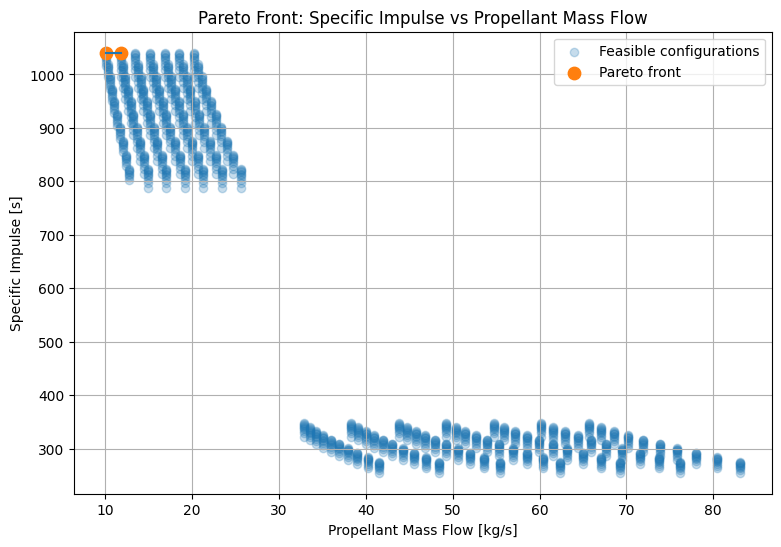

In [ ]:
# ============================================================
# PARETO OPTIMIZATION
# Maximize Specific Impulse
# Minimize Propellant Mass Flow
# Constraint: Thrust >= 100 kN
# ============================================================

# Usiamo solo le configurazioni che rispettano
# il vincolo di spinta minima

pareto_data = feasible.copy()

# Ordiniamo:
# Isp dal più alto al più basso
# Mass flow dal più basso al più alto

pareto_data = pareto_data.sort_values(
    by=["Specific_impulse_s", "Mass_flow_kg_s"],
    ascending=[False, True]
)

# Qui salveremo le configurazioni Pareto-optimal
pareto_points = []

# All'inizio non abbiamo ancora trovato
# nessuna portata minima
best_mass_flow = float("inf")


# ------------------------------------------------------------
# IDENTIFICAZIONE DEL PARETO FRONT
# ------------------------------------------------------------

for index, row in pareto_data.iterrows():

    mass_flow = row["Mass_flow_kg_s"]

    # Se questa configurazione consuma meno propellente
    # rispetto a tutte quelle già considerate,
    # appartiene al Pareto front

    if mass_flow < best_mass_flow:

        pareto_points.append(row)

        best_mass_flow = mass_flow


# Convertiamo i risultati in DataFrame
df_pareto = pd.DataFrame(pareto_points)


print("====================================")
print("PARETO OPTIMAL CONFIGURATIONS")
print("====================================")

print("Number of Pareto configurations:")
print(len(df_pareto))

print(
    df_pareto[
        [
            "System",
            "Pc_MPa",
            "Tc_K",
            "Expansion_ratio",
            "Mass_flow_kg_s",
            "Thrust_N",
            "Specific_impulse_s"
        ]
    ].round(2)
)


# ============================================================
# PARETO FRONT GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

# Tutte le configurazioni ammissibili
plt.scatter(
    feasible["Mass_flow_kg_s"],
    feasible["Specific_impulse_s"],
    alpha=0.25,
    label="Feasible configurations"
)

# Configurazioni Pareto-optimal
plt.scatter(
    df_pareto["Mass_flow_kg_s"],
    df_pareto["Specific_impulse_s"],
    s=80,
    label="Pareto front"
)

# Colleghiamo i punti Pareto
pareto_plot = df_pareto.sort_values(
    by="Mass_flow_kg_s"
)

plt.plot(
    pareto_plot["Mass_flow_kg_s"],
    pareto_plot["Specific_impulse_s"]
)

plt.title("Pareto Front: Specific Impulse vs Propellant Mass Flow")

plt.xlabel("Propellant Mass Flow [kg/s]")
plt.ylabel("Specific Impulse [s]")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# ============================================================
# EXPORT DATASETS TO CSV
# ============================================================

# Dataset completo: Chemical + NTP
df_all.to_csv(
    "rocket_propulsion_simulations.csv",
    index=False
)

# Solo configurazioni Pareto-optimal
df_pareto.to_csv(
    "pareto_optimal_configurations.csv",
    index=False
)

print("Files exported successfully:")
print("- rocket_propulsion_simulations.csv")
print("- pareto_optimal_configurations.csv")

Files exported successfully:
- rocket_propulsion_simulations.csv
- pareto_optimal_configurations.csv


# Nuova sezione